0. Library Routines 


--- Llegadas ---
Media esperada: 20
Media obtenida: 19.1971
Error: 0.8029

--- Servicios ---
Media esperada: 15
Media obtenida: 13.2079
Error: 1.7921


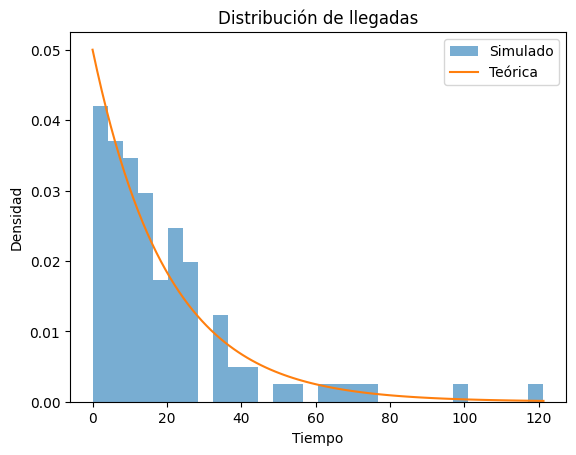

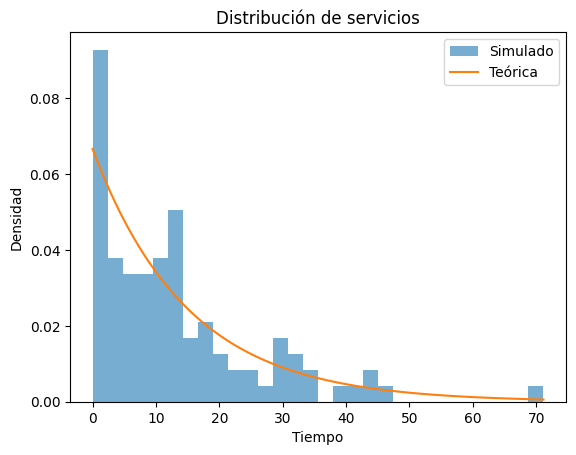

In [1]:
import math, random
import matplotlib.pyplot as plt
import numpy as np
random.seed()

######## 1. VARIABLES PARA GENERAR LOS DATOS########
media_llegadas = 20
media_servicios = 15

######## 2. FUNCIONES PARA GENERAR Y VALIDAR LOS DATOS########
#generador de tiempos exponenciales
def expon(media):
    U= random.random()
    if U == 0:
        U = 1e-10 #para evitar log(0)
    return -media*math.log(U)

#Validacion de los datos generados
def validar(datos, media_esperada, nombre):
    promedio = sum(datos) / len(datos)
    
    print(f"\n--- {nombre} ---")
    print(f"Media esperada: {media_esperada}")
    print(f"Media obtenida: {promedio:.4f}")
    print(f"Error: {abs(promedio - media_esperada):.4f}")

#Función para graficar la distribución exponencial
def graficar_exponencial(datos, media, titulo):
    plt.hist(datos, bins=30, density=True, alpha=0.6, label="Simulado")
    
    x = np.linspace(0, max(datos), 100)
    y = (1/media) * np.exp(-x/media)
    
    plt.plot(x, y, label="Teórica")
    
    plt.title(titulo)
    plt.xlabel("Tiempo")
    plt.ylabel("Densidad")
    plt.legend()
    plt.show()

############4. GENERACIÓN, VALIDACIÓN Y GRAFICACIÓN DE LOS DATOS########
llegadas = [expon(media_llegadas) for _ in range(100)]
servicios = [expon(media_servicios) for _ in range(100)]
validar(llegadas, media_llegadas, "Llegadas")
validar(servicios, media_servicios, "Servicios")
graficar_exponencial(llegadas, media_llegadas, "Distribución de llegadas")
graficar_exponencial(servicios, media_servicios, "Distribución de servicios")

1. Event List (Lista enlazada)

In [2]:
#definimos la clase Evento, esta sera los nodos
lista_eventos = None
class Evento:
    def __init__(self, tiempo, tipo):
        self.tiempo = tiempo
        self.tipo = tipo # 1 es llegada, 2 es servicio/salida
        self.siguiente = None

#funcion para eslabonar a los nodos

def insertar_evento(nuevo):
    global lista_eventos
    if lista_eventos is None or nuevo.tiempo < lista_eventos.tiempo:
        nuevo.siguiente = lista_eventos
        lista_eventos = nuevo
        return
    
    actual = lista_eventos
    while actual.siguiente and actual.siguiente.tiempo < nuevo.tiempo:
        actual = actual.siguiente
    
    nuevo.siguiente = actual.siguiente
    actual.siguiente = nuevo
    
#funcion para obtener el proximo evento
def obtener_evento():
    global lista_eventos
    
    if lista_eventos is None:
        return None
    
    evento = lista_eventos
    lista_eventos = lista_eventos.siguiente
    return evento

2. Initialization routinen

In [3]:
def inicializar():
    global tiempo_simulacion, estado_servidor, num_en_cola
    global tiempo_ultimo_evento, num_clientes_atendidos
    global total_espera, area_cola, area_servidor
    global lista_eventos, cola,media_llegadas
    
    tiempo_simulacion = 0.0
    estado_servidor = 0  # 0 = libre, 1 = ocupado
    num_en_cola = 0
    tiempo_ultimo_evento = 0.0
    
    num_clientes_atendidos = 0
    total_espera = 0.0
    area_cola = 0.0
    area_servidor = 0.0
    
    lista_eventos = None
    cola = []
    # primera llegada
    e = Evento(tiempo_simulacion + expon(media_llegadas),1)
    insertar_evento(e)

3. Timing Routine 

In [4]:
def timing():
    global tiempo_simulacion
    evento = obtener_evento()
    if evento is None:
        print("Error: lista de eventos vacía")
        return None
    
    tiempo_simulacion = evento.tiempo
    return evento.tipo



4. Event Routines

In [5]:
# Llegadas
def llegada():
    global num_en_cola, estado_servidor,num_clientes_atendidos
    
    #proxima llegada
    e = Evento(tiempo_simulacion + expon(media_llegadas), 1)
    insertar_evento(e)
    #servidor ocupado
    if estado_servidor == 1 :
        num_en_cola +=1
        cola.append(tiempo_simulacion) # se agrega a la cola
    else: #servidor vacio
        estado_servidor = 1
        num_clientes_atendidos += 1
        e = Evento(tiempo_simulacion + expon(media_servicios), 2)
        insertar_evento(e) #se programa su salida


# Salidas
def salida():
    global num_en_cola, estado_servidor
    global total_espera, num_clientes_atendidos
    #si luego de la salida ya no hay nadie
    if num_en_cola == 0:
        estado_servidor = 0
    else: # cola con clientes
        num_en_cola -= 1
        delay = tiempo_simulacion - cola.pop(0)
        total_espera += delay
        num_clientes_atendidos += 1
        e = Evento(tiempo_simulacion + expon(media_servicios), 2)
        insertar_evento(e) 

5. Update Statistics

In [6]:
def actualizar_estadisticas():
    global tiempo_ultimo_evento, area_cola, area_servidor
    
    tiempo_transcurrido = tiempo_simulacion - tiempo_ultimo_evento
    tiempo_ultimo_evento = tiempo_simulacion
    
    area_cola += num_en_cola * tiempo_transcurrido
    area_servidor += estado_servidor * tiempo_transcurrido

6. Report Generator

In [7]:
def reporte():
    print("\nSistema de colas de un solo servidor\n")
    
    print(f"Tiempo promedio entre llegadas (λ⁻¹): {media_llegadas:.3f} minutos\n")
    print(f"Tiempo promedio de servicio (μ⁻¹): {media_servicios:.3f} minutos\n")
    print(f"Número de clientes simulados: {num_clientes_atendidos}\n")
    
    print(f"Tiempo promedio en cola: {total_espera / num_clientes_atendidos:.3f} minutos\n")
    
    print(f"Promedio de clientes en cola Q(t): {area_cola / tiempo_simulacion:.3f}\n")
    
    print(f"Utilización del servidor B(t): {area_servidor / tiempo_simulacion:.3f}\n")
    
    print(f"Tiempo final de simulación: {tiempo_simulacion:.3f} minutos\n")

7. Main program

In [12]:
inicializar()
tiempos_llegadas = []
tiempos_salidas = []
eventos = []


while num_clientes_atendidos < 1000:
        tipo = timing()
        actualizar_estadisticas()
        
        if tipo == 1:
            llegada()
        else:
            salida()
reporte()





Sistema de colas de un solo servidor

Tiempo promedio entre llegadas (λ⁻¹): 20.000 minutos

Tiempo promedio de servicio (μ⁻¹): 15.000 minutos

Número de clientes simulados: 1000

Tiempo promedio en cola: 31.697 minutos

Promedio de clientes en cola Q(t): 1.587

Utilización del servidor B(t): 0.755

Tiempo final de simulación: 19974.641 minutos

